# Results

## Setup

In [18]:
# Setup

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import joblib

## Load Data

In [19]:
# load the clean datasets

df_train = pd.read_csv("data_train.csv")
df_test = pd.read_csv("data_test.csv")
print(df_train.sample(), "\n", df_test.sample())
df_test.columns

       census_tract  StCoFIPS2019 StAbbr  walkability_index  Pop2018  HU2018  \
23869   26077000500         26077     MI                7.5     4086    1958   

       HH2018  employment_mix  employment_residential_mix  \
23869    1579        0.448767                    0.352849   

       intersection_density  ...  high_cholesterol_95ci  \
23869            116.579993  ...           (20.9, 22.2)   

       kidney_disease_prevalence  kidney_disease_95ci  obesity_prevalence  \
23869                        2.1         ( 2.0,  2.2)                35.2   

       obesity_95ci  phlth_crudeprev  phlth_crude95ci  stroke_prevalence  \
23869  (33.5, 36.8)             12.2     (11.1, 13.4)                2.1   

        stroke_95ci                       geolocation  
23869  ( 2.0,  2.3)  POINT (-85.60333371 42.29732488)  

[1 rows x 57 columns] 
       census_tract  StCoFIPS2019 StAbbr  walkability_index  Pop2018  HU2018  \
6022   12099001909         12099     FL          13.666667     3109    10

Index(['census_tract', 'StCoFIPS2019', 'StAbbr', 'walkability_index',
       'Pop2018', 'HU2018', 'HH2018', 'employment_mix',
       'employment_residential_mix', 'intersection_density',
       'transit_accessibility', 'employment_mix_ranked',
       'employment_residential_mix_ranked', 'intersection_density_ranked',
       'transit_accessibility_ranked', 'median_income', 'percent_unemployed',
       'percent_below_poverty', 'percent_bachelor_and_higher',
       'percent_over_65', 'percent_commute_car', 'percent_commute_transit',
       'percent_white', 'percent_black', 'percent_native_american',
       'percent_asian', 'percent_pacific_islander', 'statedesc', 'countyname',
       'total_population', 'arthritis_crudeprev', 'arthritis_crude95ci',
       'high_blood_pressure_prevalence', 'high_blood_pressure_95ci',
       'cancer_prevalence', 'cancer_95ci', 'current_asthma_prevalence',
       'current_asthma_95ci', 'coronary_heart_disease_prevalence',
       'coronary_heart_disease_95ci'

## Configuration

In [20]:
features = [
    "employment_mix_ranked",
    "employment_residential_mix_ranked",
    "intersection_density_ranked",
    "transit_accessibility_ranked",
]

outcomes = [
    "high_cholesterol_prevalence",
    "depression_prevalence",
    "high_blood_pressure_prevalence",
    "obesity_prevalence",
    "coronary_heart_disease_prevalence",
    "cancer_prevalence",
]

[high_cholesterol_prevalence]  Train RMSE=4.044, R²=0.265 | Test RMSE=4.368, R²=0.205 | Dummy Test RMSE=5.024


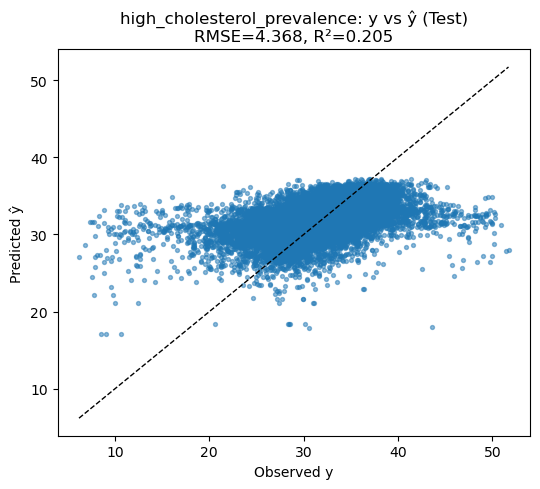

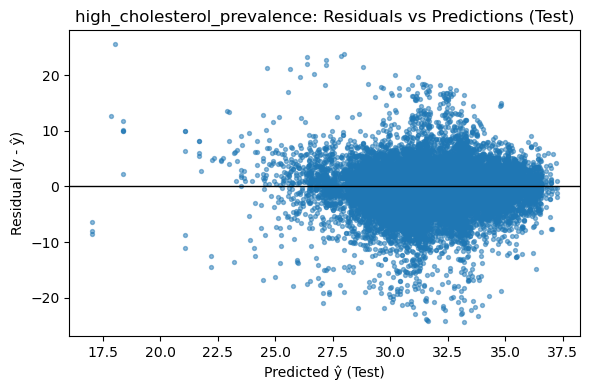

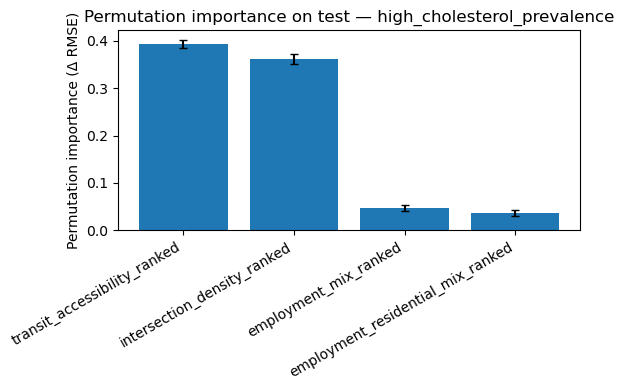

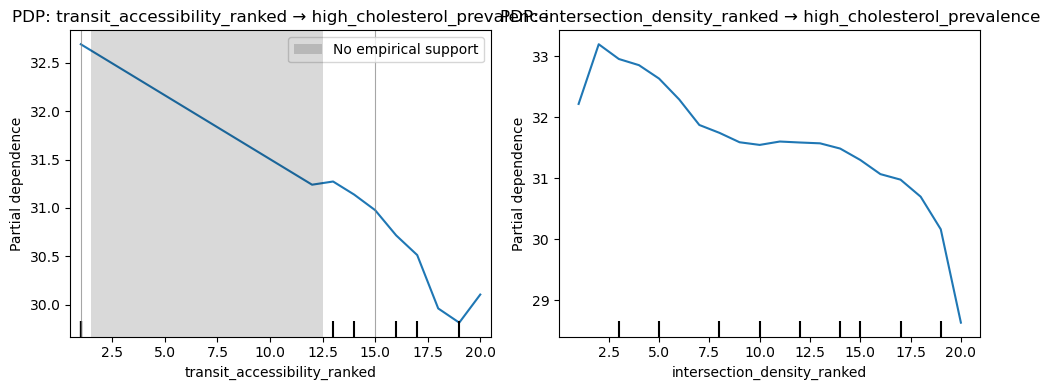

[depression_prevalence]  Train RMSE=3.085, R²=0.178 | Test RMSE=3.947, R²=0.049 | Dummy Test RMSE=4.382


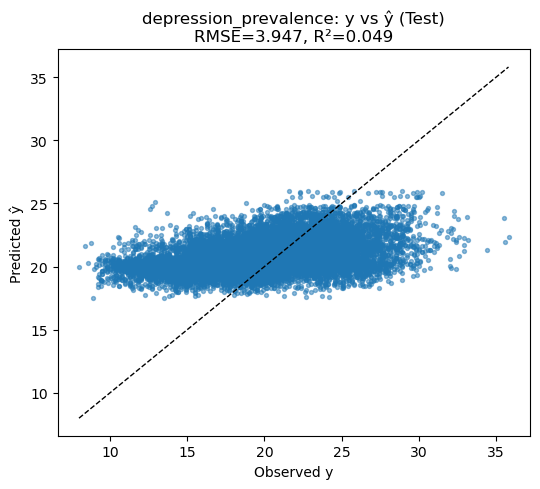

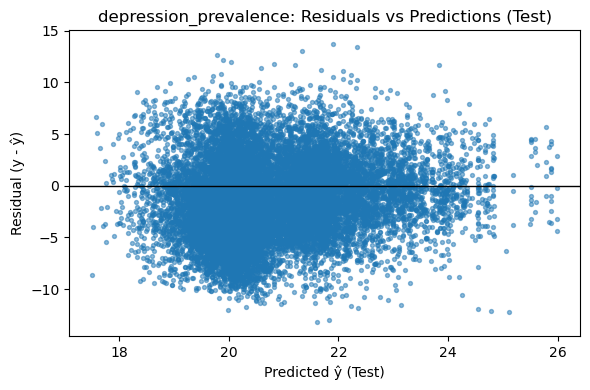

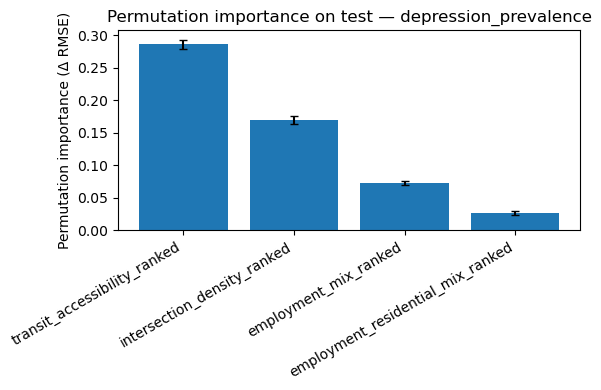

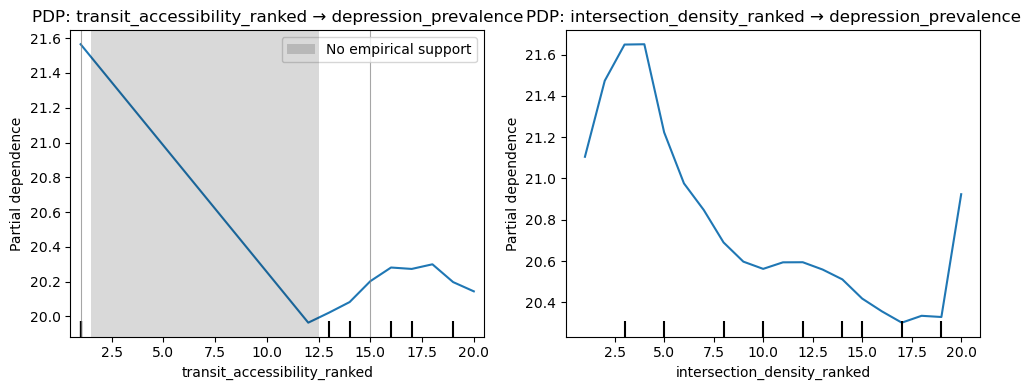

[high_blood_pressure_prevalence]  Train RMSE=6.557, R²=0.203 | Test RMSE=6.695, R²=0.129 | Dummy Test RMSE=7.452


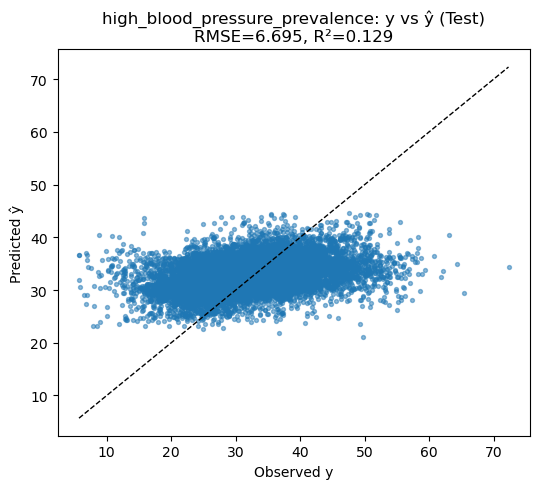

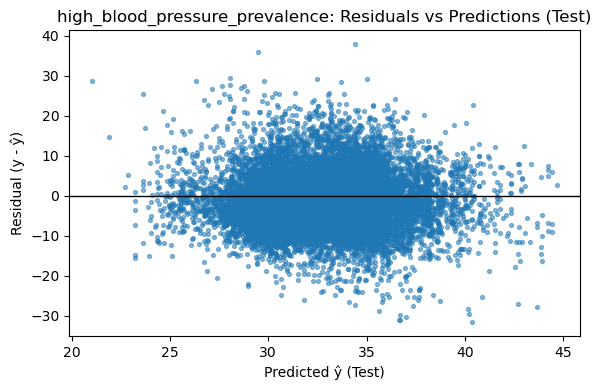

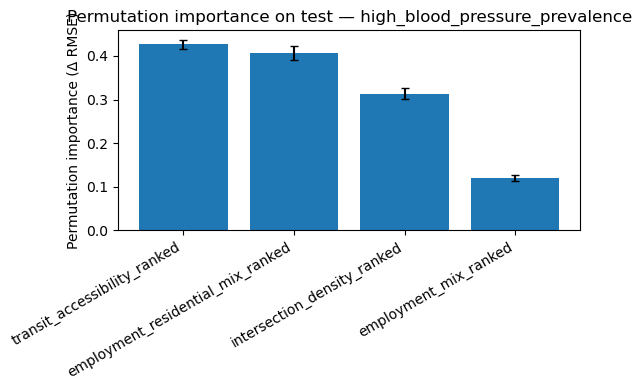

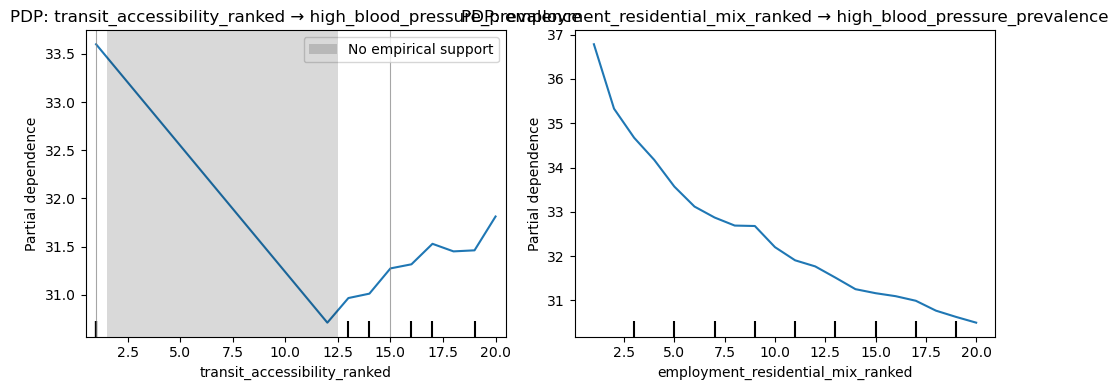

[obesity_prevalence]  Train RMSE=5.808, R²=0.243 | Test RMSE=6.554, R²=0.115 | Dummy Test RMSE=7.310


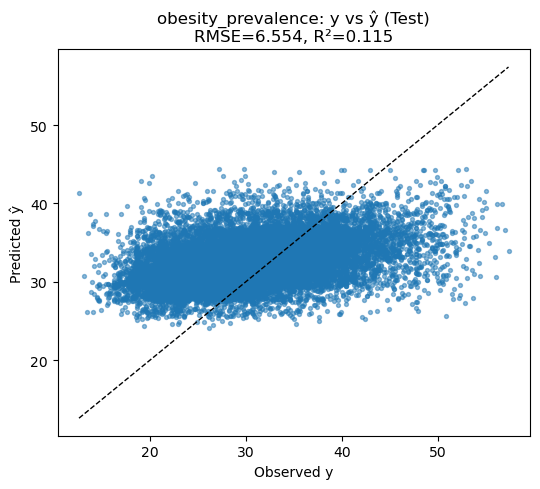

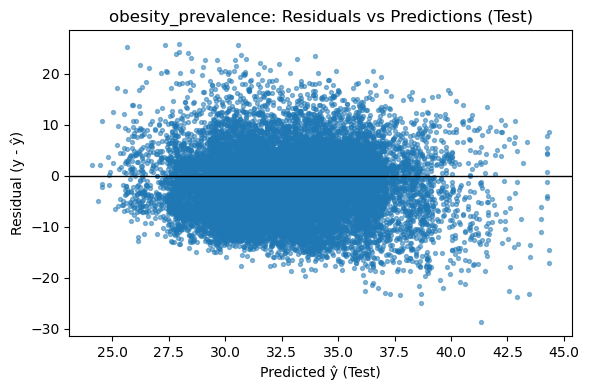

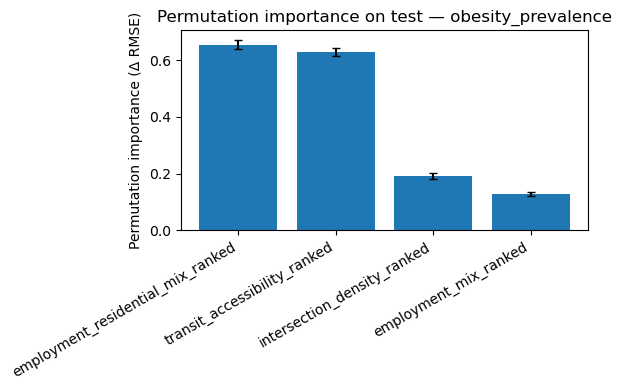

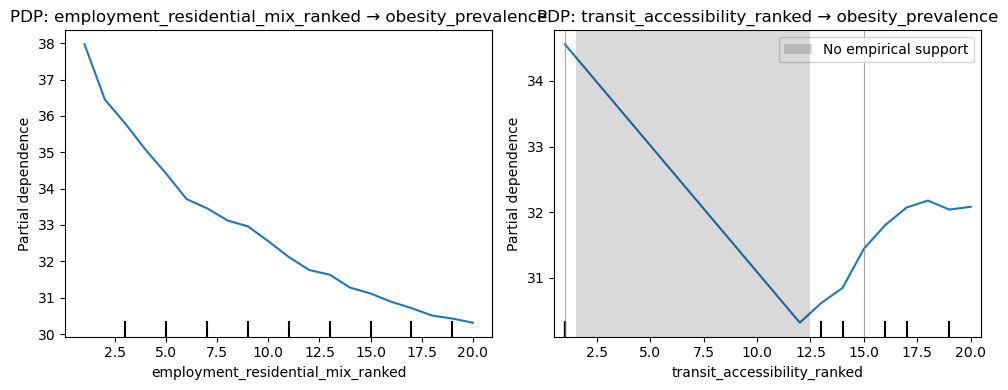

[coronary_heart_disease_prevalence]  Train RMSE=1.834, R²=0.186 | Test RMSE=1.967, R²=0.127 | Dummy Test RMSE=2.138


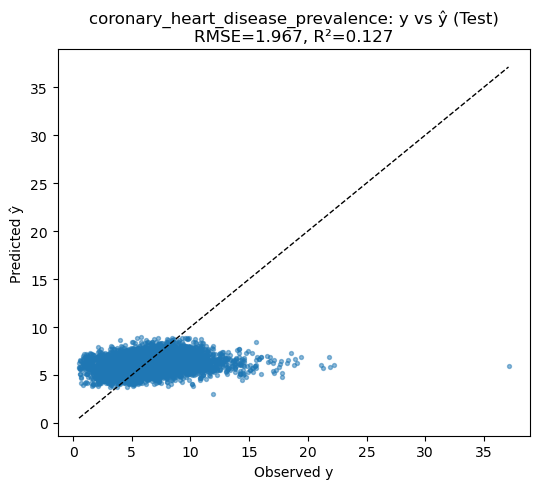

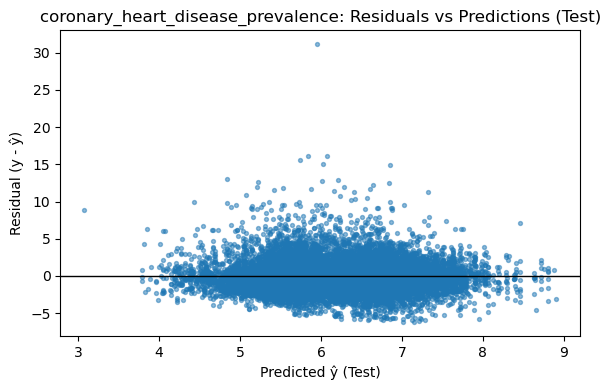

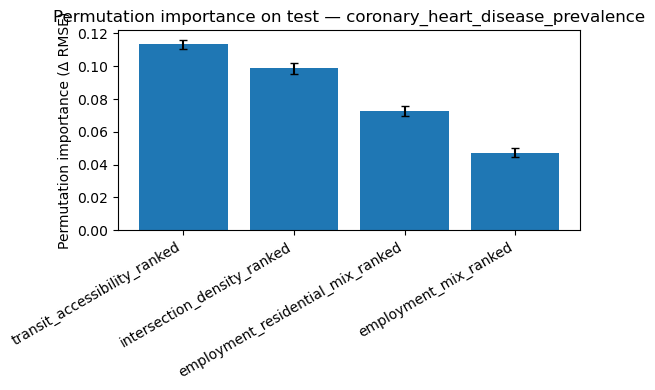

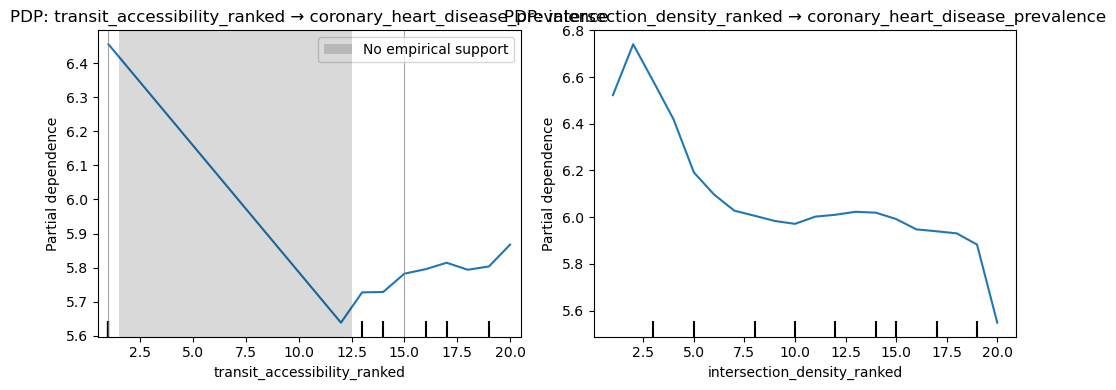

[cancer_prevalence]  Train RMSE=1.635, R²=0.233 | Test RMSE=1.936, R²=0.169 | Dummy Test RMSE=2.137


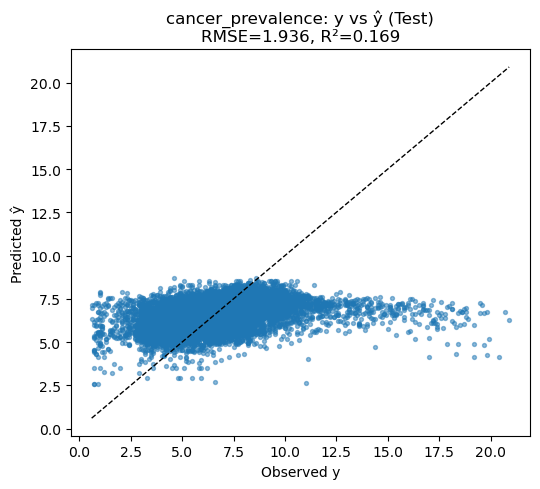

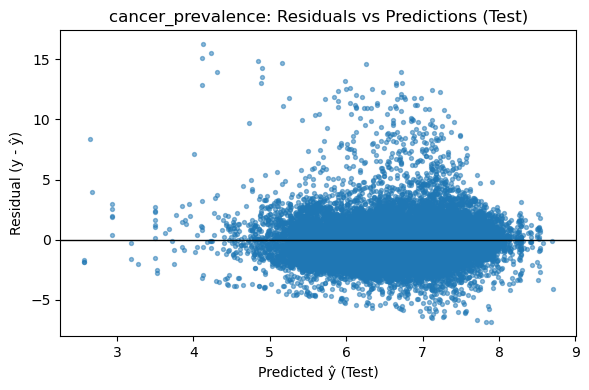

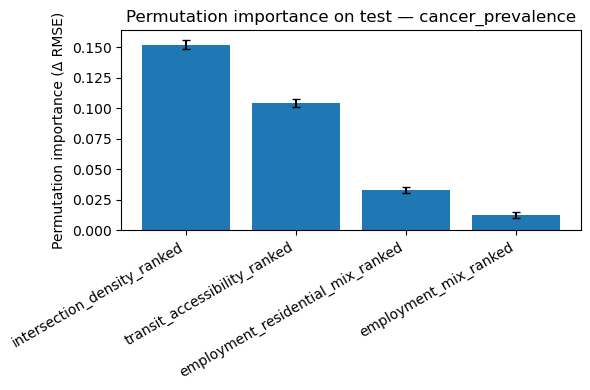

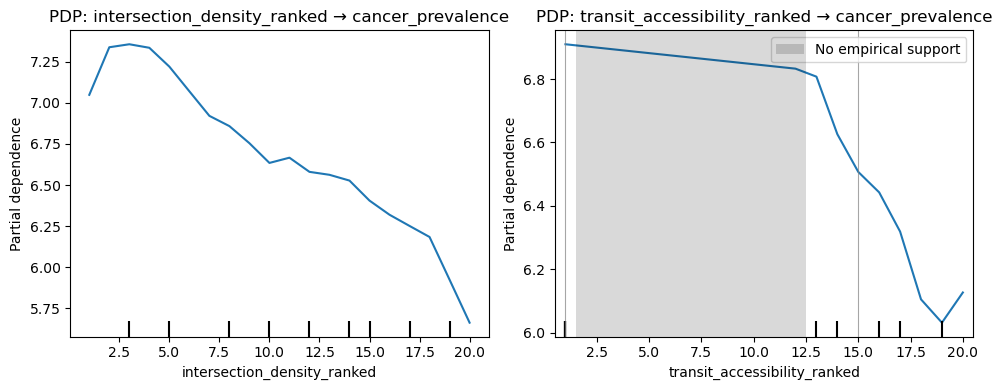

,target,rmse_train,r2_train,rmse_test,r2_test,rmse_test_dummy,best_params
0,cancer_prevalence,1.634892,0.233220,1.935798,0.168853,2.137468,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
1,coronary_heart_disease_prevalence,1.834296,0.186390,1.966954,0.126533,2.138168,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
2,depression_prevalence,3.085158,0.177962,3.947317,0.048529,4.381636,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
3,high_cholesterol_prevalence,4.044219,0.264910,4.367979,0.204672,5.023630,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
4,obesity_prevalence,5.808064,0.243436,6.553917,0.114688,7.310267,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
5,high_blood_pressure_prevalence,6.557087,0.202575,6.695075,0.128830,7.452167,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."


In [22]:
# -------------------------------
# Config: RF params (use your tuned values if you have them)
# -------------------------------
best_params = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

pipe_rf = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(**best_params)),
    ]
)

os.makedirs("final_artifacts", exist_ok=True)


def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))


summary_rows = []

for target in outcomes:
    # --- 1) Drop NaNs for this outcome separately on train/test ---
    cols_needed = features + [target]
    tr = df_train.dropna(subset=cols_needed).copy()
    te = df_test.dropna(subset=cols_needed).copy()
    if tr.empty or te.empty:
        print(f"[{target}] skipped: empty train or test after dropna.")
        summary_rows.append(
            {
                "target": target,
                "rmse_test": np.nan,
                "r2_test": np.nan,
                "rmse_train": np.nan,
                "r2_train": np.nan,
                "rmse_test_dummy": np.nan,
                "note": "empty after dropna",
            }
        )
        continue

    X_train = tr[features].to_numpy(float)
    y_train = tr[target].to_numpy(float)
    X_test = te[features].to_numpy(float)
    y_test = te[target].to_numpy(float)

    out_dir = f"final_artifacts/{target}"
    os.makedirs(out_dir, exist_ok=True)

    # --- 2) Dummy baseline (fit on train, predict test) ---
    dummy = DummyRegressor(strategy="mean")
    dummy.fit(X_train, y_train)
    yhat_test_dummy = dummy.predict(X_test)
    rmse_test_dummy = rmse(y_test, yhat_test_dummy)

    # --- 3) Fit RF on train ---
    pipe_rf.fit(X_train, y_train)

    # --- 4) Predictions & metrics ---
    yhat_train = pipe_rf.predict(X_train)
    yhat_test = pipe_rf.predict(X_test)

    rmse_train = rmse(y_train, yhat_train)
    r2_train = float(r2_score(y_train, yhat_train))
    rmse_test = rmse(y_test, yhat_test)
    r2_test = float(r2_score(y_test, yhat_test))

    print(
        f"[{target}]  Train RMSE={rmse_train:.3f}, R²={r2_train:.3f} | "
        f"Test RMSE={rmse_test:.3f}, R²={r2_test:.3f} | Dummy Test RMSE={rmse_test_dummy:.3f}"
    )

    # --- 4c) y vs ŷ (OOF on train, and Test) ---
    def plot_y_vs_yhat(y_true, y_hat, title, path):
        plt.figure(figsize=(5.5, 5))
        plt.scatter(y_true, y_hat, s=8, alpha=0.5)
        lo = min(float(np.min(y_true)), float(np.min(y_hat)))
        hi = max(float(np.max(y_true)), float(np.max(y_hat)))
        plt.plot([lo, hi], [lo, hi], "k--", lw=1)  # 45° line
        RMSE = rmse(y_true, y_hat)
        R2 = float(r2_score(y_true, y_hat))
        plt.xlabel("Observed y")
        plt.ylabel("Predicted ŷ")
        plt.title(f"{title}\nRMSE={RMSE:.3f}, R²={R2:.3f}")
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()

    plot_y_vs_yhat(
        y_test,
        yhat_test,
        f"{target}: y vs ŷ (Test)",
        f"{out_dir}/scatter_test_{target}.png",
    )
    
    # --- 4d) Residuals vs Predictions (Test) ---
    resid_test = y_test - yhat_test
    plt.figure(figsize=(6,4))
    plt.scatter(yhat_test, resid_test, s=8, alpha=0.5)
    plt.axhline(0, color='k', lw=1)
    plt.xlabel("Predicted ŷ (Test)"); plt.ylabel("Residual (y - ŷ)")
    plt.title(f"{target}: Residuals vs Predictions (Test)")
    plt.tight_layout(); plt.savefig(f"{out_dir}/residuals_vs_pred_test_{target}.png", dpi=150, bbox_inches="tight"); plt.show()


    # --- 5) Save predictions & metrics ---
    preds_train = pd.DataFrame(
        {
            "set": "train",
            "y_true": y_train,
            "y_pred": yhat_train,
            "residual": y_train - yhat_train,
        }
    )
    preds_test = pd.DataFrame(
        {
            "set": "test",
            "y_true": y_test,
            "y_pred": yhat_test,
            "residual": y_test - yhat_test,
        }
    )
    pd.concat([preds_train, preds_test]).to_csv(
        f"{out_dir}/predictions.csv", index=False
    )

    pd.DataFrame(
        [
            {
                "target": target,
                "rmse_train": rmse_train,
                "r2_train": r2_train,
                "rmse_test": rmse_test,
                "r2_test": r2_test,
                "rmse_test_dummy": rmse_test_dummy,
                "n_train": len(y_train),
                "n_test": len(y_test),
            }
        ]
    ).to_csv(f"{out_dir}/metrics.csv", index=False)

    # 6) Permutation importance on TEST (to avoid leakage) ---
    # We measure how much the model's test error increases when we randomly shuffle
    # (permute) one feature at a time. If shuffling a feature hurts performance a lot,
    # that feature was important to the model's predictions.
    r = permutation_importance(
        pipe_rf,  # fitted model (can be a Pipeline)
        X_test,  # evaluate on the held-out TEST set
        y_test,
        n_repeats=30,  # repeat the shuffle 30 times for stability
        random_state=42,  # reproducibility across runs
        n_jobs=-1,  # parallelize across CPUs
        scoring="neg_root_mean_squared_error",  # ΔRMSE (RMSE_perm - RMSE_base)
    )

    # Build a tidy table: mean importance and its std-dev across repeats
    imp = pd.DataFrame(
        {
            "feature": features,
            "perm_importance": r.importances_mean,  # mean ΔRMSE (positive = worse when shuffled)
            "sd": r.importances_std,  # variability across the n_repeats shuffles
        }
    ).sort_values("perm_importance", ascending=False)

    # Save the table for the report/notebook
    imp.to_csv(f"{out_dir}/perm_importance_test.csv", index=False)

    # --------- Plotting the importances ----------
    plt.figure(figsize=(6, 4))

    # Order features from most to least important
    order = np.argsort(imp["perm_importance"].values)[::-1]

    # Bar chart with error bars (± one std) from the repeats
    plt.bar(
        np.arange(len(features)),  # x positions: 0,1,2,... for each feature
        imp["perm_importance"].values[order],  # bar heights (mean importance)
        yerr=imp["sd"].values[order],  # error bar size (± 1 std across repeats)
        capsize=3,  # little horizontal caps on error bars
    )

    plt.xticks(
        np.arange(len(features)),  # tick positions must match the bar positions
        imp["feature"].values[order],  # the text labels shown under each bar
        rotation=30,
        ha="right",  # rotate and right-align for readability
    )

    plt.ylabel(
        "Permutation importance (Δ RMSE)"
    )  # y-axis label; bigger bar ⇒ bigger MSE increase when shuffled
    plt.title(
        f"Permutation importance on test — {target}"
    )  # figure title with outcome name
    plt.tight_layout()  # prevent label/title clipping
    plt.savefig(
        f"{out_dir}/perm_importance_test.png", dpi=150, bbox_inches="tight"
    )  # save to file
    plt.show()  # render in notebook

    # --- 7) PDPs for the top 1–2 features (on test) with shaded gap for transit ---
    top_feats = imp["feature"].head(2).tolist()
    fig, axes = plt.subplots(1, len(top_feats), figsize=(5 * len(top_feats), 4))
    if len(top_feats) == 1:
        axes = [axes]

    for ax, f in zip(axes, top_feats):
        j = features.index(f)

        # IMPORTANT: capture the display, then take the axis it actually used
        disp = PartialDependenceDisplay.from_estimator(
            pipe_rf,
            X_test,
            [j],
            feature_names=features,
            ax=ax,
            kind="average",
            centered=False,
        )
        # disp.axes_ is either a 2D array or a single Axes; normalize to an Axes object
        ax_used = (
            disp.axes_[0, 0]
            if hasattr(disp, "axes_") and np.ndim(disp.axes_) == 2
            else disp.axes_
        )

        ax_used.set_title(f"PDP: {f} → {target}")

        if f == "transit_accessibility_ranked":
            # Make sure the x-lims cover the rank range 1..20
            ax_used.set_xlim(0.5, 20.5)

            # Shade the unsupported region (1.5--12.5)
            ax_used.axvspan(
                1.5,
                12.5,
                facecolor="black",
                alpha=0.15,
                zorder=10,
                label="No empirical support",
            )

            # Optional guides at the observed edges
            ax_used.axvline(1, color="gray", lw=0.8, alpha=0.7)
            ax_used.axvline(15, color="gray", lw=0.8, alpha=0.7)

            # Add legend (avoid duplicates)
            handles, labels = ax_used.get_legend_handles_labels()
            if "No empirical support" in labels:
                ax_used.legend(loc="best")

    plt.tight_layout()
    plt.savefig(f"{out_dir}/pdp_top_features_shaded.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- 8) Save the trained model for this outcome (optional) ---
    joblib.dump(pipe_rf, f"{out_dir}/rf_model.joblib")

    # --- 9) Append to summary ---
    summary_rows.append(
        {
            "target": target,
            "rmse_train": rmse_train,
            "r2_train": r2_train,
            "rmse_test": rmse_test,
            "r2_test": r2_test,
            "rmse_test_dummy": rmse_test_dummy,
            "best_params": best_params,
        }
    )

# -------------------------------
# Final summary across outcomes
# -------------------------------
summary = pd.DataFrame(summary_rows).sort_values("rmse_test").reset_index(drop=True)
summary.to_csv("final_artifacts/summary_rf_all_outcomes.csv", index=False)
summary

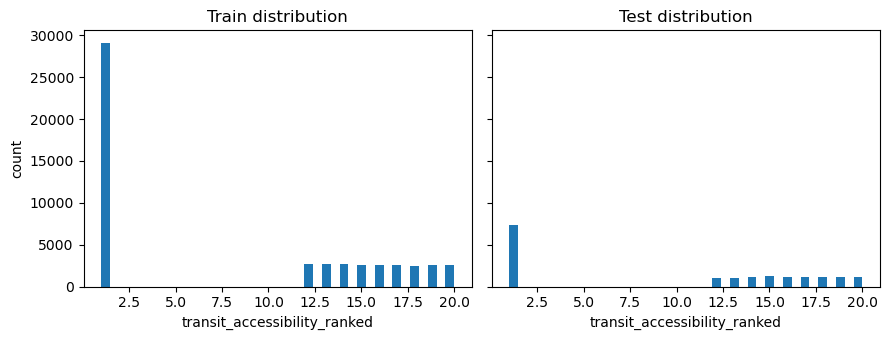

In [5]:
fig, ax = plt.subplots(1,2, figsize=(9,3.5), sharey=True)
ax[0].hist(df_train["transit_accessibility_ranked"].dropna(), bins=40)
ax[0].set_title("Train distribution")
ax[1].hist(df_test["transit_accessibility_ranked"].dropna(), bins=40)
ax[1].set_title("Test distribution")
for a in ax: a.set_xlabel("transit_accessibility_ranked")
ax[0].set_ylabel("count")
plt.tight_layout(); plt.show()

In [ ]:
def pd_curve_on_grid(model, X, j, grid):
    """
    Compute a 1D Partial Dependence (PD) curve for feature j on a chosen grid.

    Mathematically:
      PD_j(v) ≈ (1/n) * Σ_{i=1..n}  f̂( v, x_{-j}^{(i)} )

    Parameters
    ----------
    model : fitted estimator or Pipeline
        Your trained predictor (can be a scikit-learn Pipeline: imputer/scaler + RF).
    X : array-like, shape (n_samples, n_features)
        The dataset over which to average the dependence (e.g., your TEST set).
    j : int
        Column index of the feature to analyze (0-based in X).
    grid : array-like, shape (G,)
        Values of the j-th feature at which to evaluate the PD curve.

    Returns
    -------
    means : np.ndarray, shape (G,)
        The average predictions at each grid value (the PD curve).
    """
    # Ensure we have a NumPy array view of X (won't modify caller's data)
    X = np.asarray(X)

    # Prepare output: one mean prediction per grid value
    means = np.empty(len(grid), dtype=float)

    # Loop over grid values v
    for t, v in enumerate(grid):
        # Make a copy so we don't overwrite the original X
        Xv = X.copy()

        # Set the j-th feature to v for *all* rows (holding others fixed)
        # This constructs the counterfactual batch (v, x_{-j}^{(i)})
        Xv[:, j] = v

        # Predict on this counterfactual batch, then average across rows
        means[t] = model.predict(Xv).mean()

    # Return the PD curve sampled on 'grid'
    return means

In [ ]:
from sklearn.base import clone
import numpy as np


def pd_bootstrap_band_refit(
    pipe_template,  # UNFITTED Pipeline/estimator (we clone & fit each draw)
    X_train,
    y_train,  # training data (numpy arrays)
    X_test,  # test data used to compute the PDP averages
    j,
    grid,  # feature index j, and 1D array of values at which to evaluate PDP
    B=150,  # number of bootstrap draws (refits)
    alpha=0.10,  # central (1 - alpha) band: e.g., 0.10 → 10–90% band
    frac_train=0.7,  # m-out-of-n fraction for bootstrapping TRAIN rows
    frac_test=0.7,  # m-out-of-n fraction for bootstrapping TEST rows (for PDP averaging)
    groups_train=None,  # optional group labels (e.g., county) for TRAIN resampling
    groups_test=None,  # optional group labels for TEST resampling
    omega_train=None,  # optional per-row SEs for labels (used for noise/weights)
    add_label_noise=False,  # if True: y*_b = y + Normal(0, omega^2) each draw
    weight_by_omega=False,  # if True: fit with sample_weight = 1 / (omega^2 + eps)
):
    # RNG for reproducibility
    rng = np.random.default_rng(42)

    # Ensure numeric arrays
    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    X_test = np.asarray(X_test, float)
    grid = np.asarray(grid, float)

    n_tr = len(X_train)
    n_te = len(X_test)

    # ---------------------------
    # Helper: resample indices
    # ---------------------------
    # Returns bootstrap indices either by rows (no groups) or by resampling groups
    # and concatenating their member rows. 'frac' controls m-out-of-n thickness.
    def _resample_indices(n, frac, groups=None):
        if groups is None:
            m = max(2, int(frac * n))
            return rng.integers(0, n, size=m)  # sample row indices with replacement
        else:
            g = np.asarray(groups)
            uniq = np.unique(g)  # unique groups
            m_groups = max(2, int(frac * len(uniq)))  # how many groups to draw
            chosen = rng.choice(uniq, size=m_groups, replace=True)
            # stack all rows from the chosen groups
            idx_blocks = [np.where(g == gg)[0] for gg in chosen]
            idx = np.concatenate(idx_blocks)
            return idx

    curves = []  # will store PDP curves (one per bootstrap draw)

    for _ in range(B):
        # ---------------------------
        # 1) Bootstrap TRAIN subset
        # ---------------------------
        idx_tr = _resample_indices(n_tr, frac_train, groups_train)
        X_tr_b = X_train[idx_tr]
        y_tr_b = y_train[idx_tr]

        # (Optional) Inject label noise to reflect outcome-estimation uncertainty
        # y*_b = y + Normal(0, omega^2). Requires omega_train.
        if add_label_noise:
            assert (
                omega_train is not None
            ), "Provide omega_train if add_label_noise=True."
            noise = rng.normal(0.0, omega_train[idx_tr])
            y_tr_b = y_tr_b + noise

        # (Optional) Heteroskedastic weighting: rows with larger omega get down-weighted.
        fit_kwargs = {}
        if weight_by_omega:
            assert (
                omega_train is not None
            ), "Provide omega_train if weight_by_omega=True."
            sw = 1.0 / (omega_train[idx_tr] ** 2 + 1e-8)  # stability epsilon
            # Pass sample_weight to the RF step inside your Pipeline.
            # If your RF step name is not 'rf', change the key below to '<stepname>__sample_weight'.
            fit_kwargs = {"rf__sample_weight": sw}

        # ---------------------------
        # 2) Fit a fresh clone
        # ---------------------------
        # Clone removes any fitted state and keeps the same hyperparameters as template.
        est = clone(pipe_template)
        # If we provided weights, pass them into .fit; otherwise plain fit.
        est.fit(X_tr_b, y_tr_b, **fit_kwargs) if fit_kwargs else est.fit(X_tr_b, y_tr_b)

        # ---------------------------
        # 3) Bootstrap TEST subset
        # ---------------------------
        # We average PDP on a resampled slice of test (stabilizes variability and
        # gives uncertainty that reflects finite-sample averaging).
        idx_te = _resample_indices(n_te, frac_test, groups_test)
        X_te_b = X_test[idx_te]

        # ---------------------------
        # 4) Compute PDP curve on grid
        # ---------------------------
        # pd_curve_on_grid implements: PD_j(v) = mean_i f_hat(v, x_{-j}^{(i)})
        curves.append(pd_curve_on_grid(est, X_te_b, j, grid))

    # Stack all bootstrap curves → shape (B, len(grid))
    curves = np.vstack(curves)

    # Pointwise mean and percentile band
    mean = curves.mean(axis=0)
    lo = np.percentile(curves, 100 * alpha / 2, axis=0)
    hi = np.percentile(curves, 100 * (1 - alpha / 2), axis=0)

    # Guard against degenerate zero-width bands due to numeric equality
    if np.allclose(lo, hi):
        hi = hi + 1e-12

    return grid, mean, lo, hi

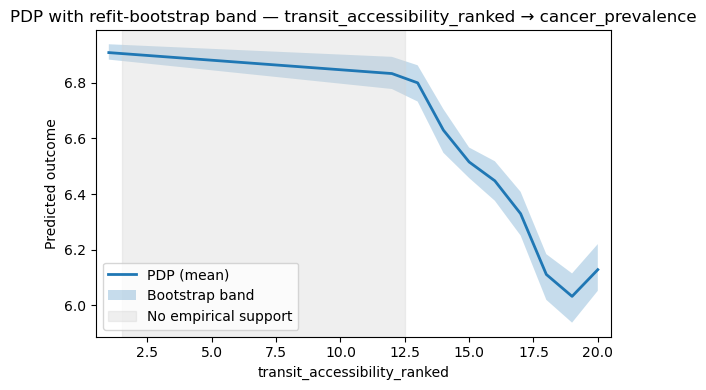

In [16]:
import matplotlib.pyplot as plt
from sklearn.base import clone

# Case A: you already have a configured pipeline/estimator called `pipe_rf`
# (e.g., Pipeline([("pre", pre_plain), ("rf", RandomForestRegressor(...))]))
pipe_rf_template = clone(pipe_rf)


# Choose feature
feat = "transit_accessibility_ranked"  # or "intersection_density_ranked", etc.
j = features.index(feat)


# Use *observed* support for gappy ranks (cleanest)
grid = np.sort(np.unique(X_test[:, j]).astype(float))

# IMPORTANT: pipe_template must be an *unfitted* pipeline with your best params
# Example:
# from sklearn.pipeline import Pipeline
# pipe_template = Pipeline([
#     ("imp", SimpleImputer(strategy="median")),
#     ("rf", RandomForestRegressor(**best_params))  # same params you selected
# ])

grid, mean, lo, hi = pd_bootstrap_band_refit(
    pipe_template=pipe_rf_template,  # unfitted template (NOT the already-fitted pipe)
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    j=j,
    grid=grid,
    B=120,  # bump to 200+ if you have time
    alpha=0.10,  # 10–90% band; use 0.05 for 95%
    frac_train=0.7,  # 70% m-out-of-n bootstrap on train
    frac_test=0.7,  # 70% m-out-of-n bootstrap on test
    groups_train=None,  # or your county labels if you have them
    groups_test=None,  # same
    omega_train=omega_train if "omega_train" in globals() else None,
    add_label_noise=False,  # True if you want to reflect BRFSS SEs in y during refit
    weight_by_omega=False,  # True if you want WLS-style weighting during fit
)

plt.figure(figsize=(6, 4))
plt.plot(grid, mean, lw=2, label="PDP (mean)")
plt.fill_between(grid, lo, hi, alpha=0.25, label="Bootstrap band")

# Optional: shade unsupported ranks if you ever use a dense grid
if feat == "transit_accessibility_ranked":
    plt.xlim(0.5, 20.5)
    plt.axvspan(1.5, 12.5, color="lightgray", alpha=0.35, label="No empirical support")

plt.xlabel(feat)
plt.ylabel("Predicted outcome")
plt.title(f"PDP with refit-bootstrap band — {feat} → {target}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/pdp_bootstrap_refit_{feat}.png", dpi=150, bbox_inches="tight")
plt.show()